### Project : House Price Prediction using Linear Regression

### Problem Statement

In the real estate industry, accurately predicting house prices is crucial for buyers, sellers, and investors. Property prices depend on multiple factors such as location, size, number of bedrooms, etc.

The challenge is to build a machine learning model that can predict house prices based on multiple features, helping stakeholders make informed decisions.

### Objective

The main objectives of this project are:

- Predict house prices using multiple features
- Perform encoding for categorical variables
- Build a pipeline-based Linear Regression model
- Evaluate performance using regression metrics
- Extract meaningful insights from housing data

### STEP 1: DATA LOADING + CLEANING

In [2]:
import pandas as pd

# load data
df = pd.read_csv("House_Data.csv")

# preview
print(df.head())

# drop unnecessary column
df = df.drop("id", axis=1)

# check again
print(df.info())

   id  house_size_sqft  num_bedrooms  age_of_house_years  location house_type  \
0   1          3377.42             1                  47  Suburban      Villa   
1   2          4514.81             1                  37  Suburban  Apartment   
2   3          1483.87             5                  38     Urban      Villa   
3   4          4411.85             2                  44  Suburban   Bungalow   
4   5          1468.91             3                   6     Urban  Townhouse   

   condition      furnishing  house_price_usd  
0    Average     Unfurnished        614992.29  
1       Poor     Unfurnished        735642.67  
2  Excellent     Unfurnished        417046.99  
3       Good     Unfurnished        772604.15  
4       Poor  Semi-Furnished        384795.11  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   house_size_sqft   

In [3]:
df.head()

,house_size_sqft,num_bedrooms,age_of_house_years,location,house_type,condition,furnishing,house_price_usd
0,3377.42,1,47,Suburban,Villa,Average,Unfurnished,614992.29
1,4514.81,1,37,Suburban,Apartment,Poor,Unfurnished,735642.67
2,1483.87,5,38,Urban,Villa,Excellent,Unfurnished,417046.99
3,4411.85,2,44,Suburban,Bungalow,Good,Unfurnished,772604.15
4,1468.91,3,6,Urban,Townhouse,Poor,Semi-Furnished,384795.11


### STEP 2: DEFINE X and y

In [4]:
X = df.drop("house_price_usd", axis=1)
y = df["house_price_usd"]

### STEP 3: SPLIT FEATURES

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### STEP 4: FEATURE ENGINEERING

#### Step 4.1: Identify Columns

In [6]:
# categorical columns
cat_cols = ["location", "house_type", "condition", "furnishing"]

# numerical columns
num_cols = ["house_size_sqft", "num_bedrooms", "age_of_house_years"]

#### Step 4.2: Import Required Libraries

In [7]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

#### Step 4.3: Create Transformer

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first"), cat_cols)
    ]
)

#### WHY WE DID THIS

- StandardScaler

Makes all numerical features same scale
Improves model performance

- OneHotEncoder

Converts categories into numbers
Avoids wrong ordering (unlike LabelEncoder )

- drop="first"

Prevents dummy variable trap

### STEP 5: BUILD PIPELINE

- Import

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

- Create Pipeline

In [10]:
model = Pipeline(steps=[
     ("preprocessing", preprocessor),
    ("regressor", LinearRegression())
])

#### WHY WE USE PIPELINE 


- Prevents data leakage
- Ensures same preprocessing on train & test
- Clean and reusable code
- Industry standard approach

### STEP 6: TRAIN MODEL

In [11]:
model.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### STEP 7: PREDICTION

In [12]:
y_pred = model.predict(X_test)

### STEP 8: EVALUATION

In [14]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("MAE:", mae)


R2 Score: 0.9984467942495208
MAE: 6551.2834105668935


### STEP 9: VISUALIZATION

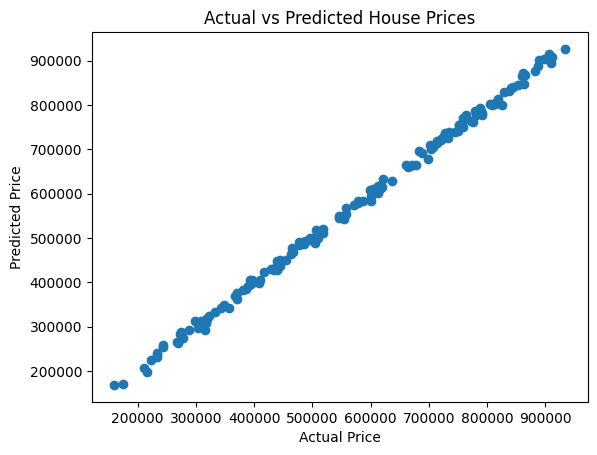

In [15]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

### Key Insights:
- House size is the strongest factor affecting price
- Newer houses tend to have higher value
- Furnishing and condition significantly impact pricing
- Location plays a critical role in price variation
- Model shows strong linear dependency between features and price

### FINAL CONCLUSION


- The Linear Regression model performed exceptionally well with an R² score of 0.998, indicating a strong ability to predict house prices. The low MAE suggests minimal prediction error. The use of a pipeline ensured clean preprocessing and robust model building. However, further validation is recommended to ensure generalization.